In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import copy
import wandb
from tqdm.auto import tqdm

import sys
sys.path.append('../scripts')

from functions import * 

In [2]:
print(torch.__version__)
torch.cuda.is_available()

2.13.0+cu130


True

In [3]:
df_patch0 = load_data(0)

Data for Patch 0


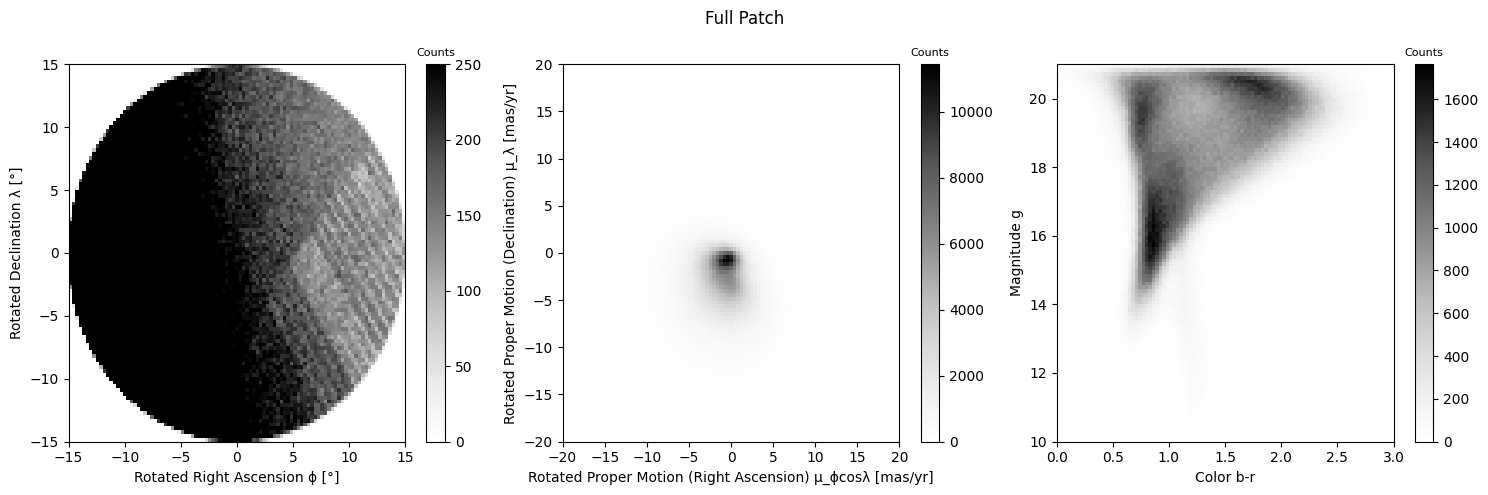

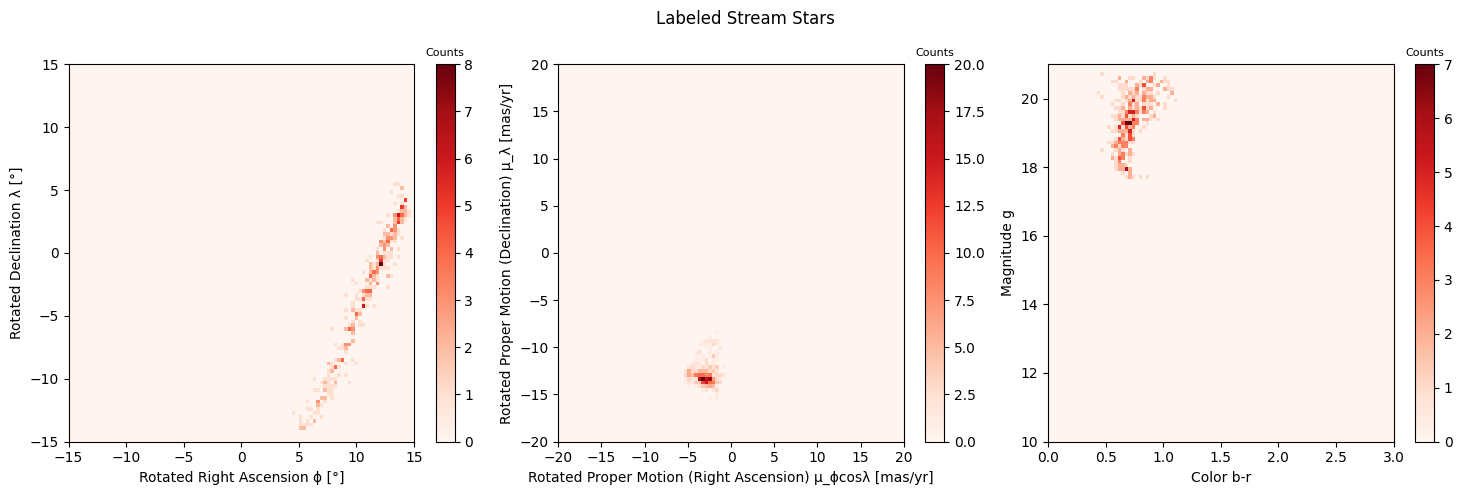

In [4]:
plot_data(df_patch0, save_folder = None)

Signal parameter: Rotated and Centered Proper Motion (DEC) μ_λ
Signal region factor = 1 and sideband region factor = 3
Signal parameter median = -13.147
Signal parameter standard deviation = 1.163
Signal Region Range: [-14.310, -11.984]
Sideband Region Range: [-16.636, -14.310) and (-11.984, -9.658]
Signal Region has 51528 stars, 307 stream and 51221 background.
Sideband Region has 118124 stars, 57 stream and 118067 background.
Outer Region has 2021540 stars, 14 stream and 2021526 background.


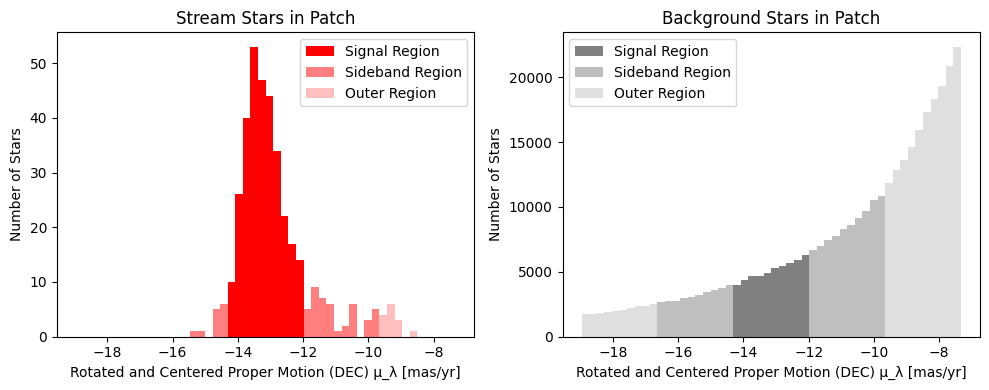

In [5]:
df_regions = signal_sideband(df_patch0, save_folder = None, pm_parameter='rotpmdec', 
                             sig_factor=1, sb_factor=3)

In [6]:
df = df_regions
pm_parameter='rotpmdec'
dropout=0.2
k_folds=5
batch_size=10000
lr=0.001
patience=30
epochs=100
trainval_loops=3    

In [7]:
# denotes training variables, separate from proper motion parameter used to define signal/sideband regions
training_vars = ['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']

# model architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=dropout): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [8]:
# k-folding
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=18)

fold_stars = [] # will become a list of k (5) arrays, representing the k folds
for fold_idx, (train_index, test_index) in enumerate(skf.split(df[training_vars], df['region_label'])):
    fold_stars.append(test_index)
fold_labels = np.arange(len(fold_stars)) # fold labels is an array of values 0-4, representing indices/labels of the 5 folds
print('done')

done


In [9]:
import time

In [10]:
print('start')
torch.cuda.synchronize()
training_start = time.time()

test_dfs = []
for test_idx in fold_labels: # loops through each fold as the test fold
    print('-----------------------------------------------')
    print(' ')
    print(f'Test fold {test_idx}...')
    
    test_stars = fold_stars[test_idx]

    test_nn_scores = []
    for val_idx in np.delete(fold_labels, test_idx): # cycles through remaining sets (minus the test set) for validation sets
        print(f'Validation fold {val_idx}...')
        val_stars = fold_stars[val_idx]

        train_indices = np.delete(fold_labels, [test_idx, val_idx])
        train_stars = np.concatenate([fold_stars[train_idx] for train_idx in train_indices])

        df_train = df.iloc[train_stars] # create data frames with indices
        df_val = df.iloc[val_stars]
        df_test = df.iloc[test_stars]

        train_x = df_train[training_vars]
        train_y = df_train['region_label'].to_numpy()

        val_x = df_val[training_vars]
        val_y = df_val['region_label'].to_numpy()

        test_x = df_test[training_vars]
        test_y = df_test['region_label'].to_numpy()
        test_y_true = df_test['stream'].to_numpy(dtype=int)

        scaler = StandardScaler() # scale data to standardize with mean of 0 and standard deviation of 1
        
        train_x = scaler.fit_transform(train_x) # fit_transform called only on train data
        val_x = scaler.transform(val_x)
        test_x = scaler.transform(test_x)
                
        # create tensors, datasets, and loaders
        train_x_tensor = torch.tensor(np.array(train_x), dtype=torch.float32)
        train_y_tensor = torch.tensor(train_y, dtype=torch.float32)
            
        val_x_tensor = torch.tensor(np.array(val_x), dtype=torch.float32)
        val_y_tensor = torch.tensor(val_y, dtype=torch.float32)
            
        test_x_tensor = torch.tensor(np.array(test_x), dtype=torch.float32)
        test_y_tensor = torch.tensor(test_y, dtype=torch.float32)
        test_y_true_tensor = torch.tensor(test_y_true, dtype=torch.long)
            
        train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
        val_dataset = TensorDataset(val_x_tensor, val_y_tensor)
        test_dataset = TensorDataset(test_x_tensor, test_y_tensor, test_y_true_tensor)
            
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=8, persistent_workers=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=8, persistent_workers=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=8, persistent_workers=True)

        best_loop_val_loss = float('inf')
        
        for n in range(trainval_loops): # trains the model trainval_loops number of times (equal to the number of remaining folds, used as training)
            print(f'Starting training loop {n+1}')
                
            # initialize model upon each training loop
            model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=dropout).to(device)
            model = torch.compile(model)
            
            loss_fn = nn.BCELoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            best_val_loss = float('inf')
            patience_counter = 0
            
            for epoch in tqdm(range(100), desc='Epochs'):
            
                # training
                model.train()
                
                total_train_loss = torch.tensor(0.0, device=device)
                train_correct = torch.tensor(0.0, device=device)
                counts = 0
                
                for inputs, region_labels in train_loader:
                    inputs = inputs.to(device, non_blocking=True)
                    region_labels = region_labels.to(device, non_blocking=True)


                    optimizer.zero_grad()
                    out = model(inputs).squeeze(1) # forward pass
                    loss = loss_fn(out, region_labels) # compute loss
                    loss.backward()
                    optimizer.step()
                    total_train_loss += loss.detach() * inputs.size(0)
                
                    predictions = (out > 0.5).float()
                    train_correct += (predictions == region_labels).sum()
                    counts += region_labels.size(0)

                
                avg_train_loss = (total_train_loss / counts).item()  
                train_accuracy = (train_correct / counts).item()
                
                # validation, used to track loss/accuracy, monitor for early stopping
                model.eval()
                total_val_loss = torch.tensor(0.0, device=device)
                val_correct = torch.tensor(0.0, device=device)
                counts = 0
                with torch.no_grad():
                    for inputs, region_labels in val_loader:
                        inputs = inputs.to(device, non_blocking=True)
                        region_labels = region_labels.to(device, non_blocking=True)
                        
                        out = model(inputs).squeeze(1)
                        loss = loss_fn(out, region_labels)
                        total_val_loss += loss.detach() * inputs.size(0)
                
                        predictions = (out > 0.5).float()
                        val_correct += (predictions == region_labels).sum()
                        counts += region_labels.size(0)
            
                avg_val_loss = (total_val_loss / counts).item()
                val_accuracy = (val_correct / counts).item()

                # early stopping
                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    patience_counter = 0
                    best_model = copy.deepcopy(model.state_dict())
                else:
                    patience_counter += 1
            
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch} with average val_loss {avg_val_loss}")
                    break
            
            if best_val_loss < best_loop_val_loss:
                best_loop_val_loss = best_val_loss
                lowest_val_loss_model = best_model ## model parameters from epoch with the lowest validation loss

                
        print(f'Best validation loss for validation fold label {val_idx} = {best_val_loss}')

        model.load_state_dict(lowest_val_loss_model) ## test set evaluated on the best model from each of the 4 validation sets

        model.eval()
        test_loss, test_correct, counts = 0.0, 0.0, 0
        raw_scores = []

        print('Testing...')
        with torch.no_grad():
            for inputs, region_labels, true_labels in test_loader:
                inputs = inputs.to(device, non_blocking=True)
                region_labels = region_labels.to(device, non_blocking=True)
                out = model(inputs).squeeze()
                raw_scores.extend(out.squeeze().cpu().numpy())
        
        test_nn_scores.append(raw_scores)
        print(f'Test scores saved for test fold {test_idx} val fold {val_idx}.')

    print('Averaging nn_scores for each star from the 4 best models...')
    df_test['nn_score'] = np.mean(test_nn_scores, axis=0)
    test_dfs.append(df_test)

df_test_full = pd.concat([df for df in test_dfs])

print('Full test df done!')

# ... training ...
torch.cuda.synchronize()
time.time() - training_start

start
-----------------------------------------------
 
Test fold 0...
Validation fold 1...
Starting training loop 1


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Starting training loop 2


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Early stopping at epoch 98 with average val_loss 0.6132195591926575
Starting training loop 3


...

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Starting training loop 3


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Best validation loss for validation fold label 3 = 0.6125080585479736
Testing...
Test scores saved for test fold 4 val fold 3.
Averaging nn_scores for each star from the 4 best models...
Full test df done!


1849.689942598343

In [12]:
def get_results(df, top_n=250, fid_cuts=True, patch_idx=0):

    if fid_cuts:
        df = fiducial_cuts(df)
        print('Plotting after fiducial cuts...')
    else:
        print('Plotting before fiducial cuts..')
    
    df_signalreg = df[df['region_label']==1]
    df_backgroundreg = df[df['region_label']==0]

    df_streamstar = df[df['stream']==True]
    df_backgroundstar = df[df['stream']==False]

    # NN scores
    plt.figure()
    plt.hist(df_signalreg['nn_score'], label='Signal Region', histtype='step', bins=50)
    plt.hist(df_backgroundreg['nn_score'], label='Background Region', histtype='step', bins=50)
    plt.xlabel('NN Score')
    plt.ylabel('Number of Stars')
    plt.legend()
    plt.show()

    plt.figure()
    plt.hist(df_streamstar['nn_score'], label='Stream Stars', color='red', histtype='step', bins=50)
    plt.hist(df_backgroundstar['nn_score'], label='Background Stars', color='grey', histtype='step', bins=50)
    plt.yscale('log')
    plt.xlabel('NN Score')
    plt.ylabel('Number of Stars')
    plt.legend()
    plt.show()

    # top N stars
    df_ranked = df.sort_values(by='nn_score', ascending=False)
    df_top = df_ranked[:top_n]

    # purity and completeness
    purity, completeness = compute_purity_and_completeness(df, top_n=top_n)
    print(f'Top {top_n} ranked stars: Purity = {purity*100:.2f}%')
    print(f'Top {top_n} ranked stars: Completeness = {completeness*100:.2f}%')

    # plot cwola stars on top of gaia stars
    df_top_signal = df_top[df_top['stream']==True]
    df_top_background = df_top[df_top['stream']==False]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
    fig.suptitle(f'Patch {patch_idx}: CWoLa Top Matches, purity = {purity*100:.2f}%')
    
    axes[0].scatter(df_streamstar['ra'], df_streamstar['dec'], label='GD-1 Stars', color='grey', marker='.', s=5)
    axes[0].scatter(df_top_signal['ra'], df_top_signal['dec'], label='CWoLa Matches', color='red', marker='.', s=5)
    axes[0].scatter(df_top_background['ra'], df_top_background['dec'], label='CWoLa Non-Matches', color='blue', marker='.', s=5)
    axes[0].set_xlabel('Right Ascension α [°]', fontsize = 10)
    axes[0].set_ylabel('Declination δ [°]', fontsize = 10)
    axes[0].legend()

    axes[1].scatter(df_streamstar['rotpmra'], df_streamstar['rotpmdec'], label='GD-1 Stars', color='grey', marker='.', s=5)
    axes[1].scatter(df_top_signal['rotpmra'], df_top_signal['rotpmdec'], label='CWoLa Matches', color='red', marker='.', s=5)
    axes[1].scatter(df_top_background['rotpmra'], df_top_background['rotpmdec'], label='CWoLa Non-Matches', color='blue', marker='.', s=5)
    axes[1].set_xlabel('Rotated Proper Motion (Right Ascension) μ_ϕcosλ [mas/yr]', fontsize = 10)
    axes[1].set_ylabel('Rotated Proper Motion (Declination) μ_λ [mas/yr]', fontsize = 10)

    axes[2].scatter(df_streamstar['b-r'], df_streamstar['g'], label='GD-1 Stars', color='grey', marker='.', s=5)
    axes[2].scatter(df_top_signal['b-r'], df_top_signal['g'], label='CWoLa Matches', color='red', marker='.', s=5)
    axes[2].scatter(df_top_background['b-r'], df_top_background['g'], label='CWoLa Non-Matches', color='blue', marker='.', s=5)
    axes[2].set_xlabel('Color b-r', fontsize = 10)
    axes[2].set_ylabel('Magnitude g', fontsize = 10)

    plt.tight_layout()
    plt.show()

Plotting after fiducial cuts...


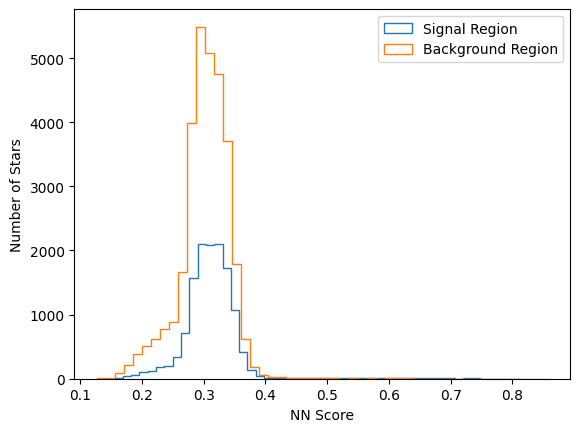

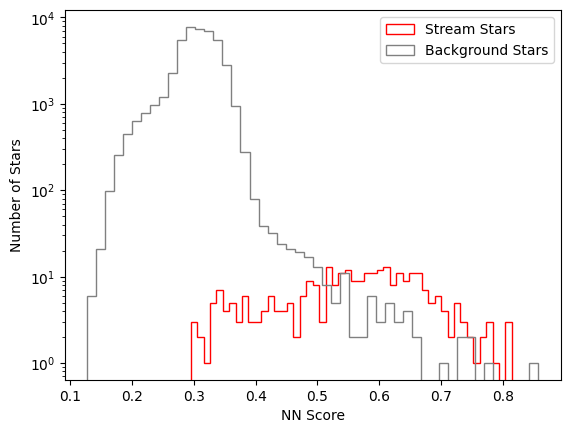

Top 250 ranked stars: Purity = 78.00%
Top 250 ranked stars: Completeness = 65.88%


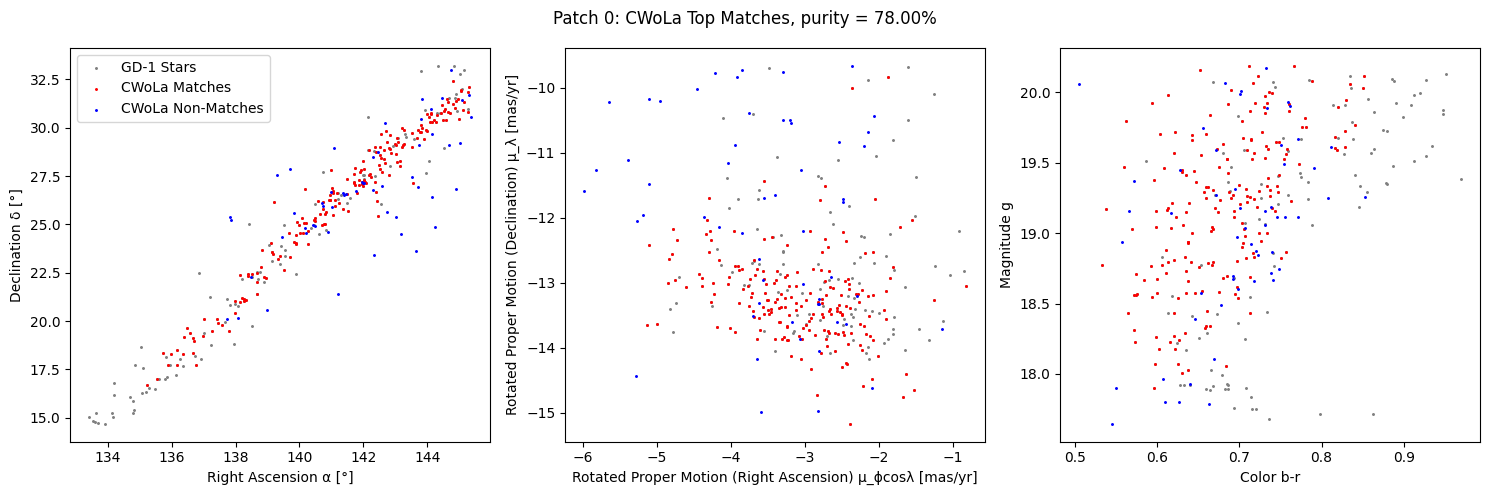

In [14]:
get_results(df_test_full, top_n=250, fid_cuts=True, patch_idx=0)